<a href="https://colab.research.google.com/github/areeba-muddasar/Decodelabs_tasks/blob/main/Data_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 2: Load Iris Dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("--- First 5 rows ---")
print(df.head())
print(f"\nShape: {df.shape} (150 rows, 5 columns)")
print(f"Classes: {iris.target_names}")

--- First 5 rows ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Shape: (150, 5) (150 rows, 5 columns)
Classes: ['setosa' 'versicolor' 'virginica']


In [7]:
# Step 3: Feature Scaling
X = df.drop('target', axis=1)  # Features
y = df['target']               # Target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")
print(f"Mean after scaling: {X_scaled.mean(axis=0).round(2)}")
print(f"Std after scaling:  {X_scaled.std(axis=0).round(2)}")

Data scaled successfully!
Mean after scaling: [-0. -0. -0. -0.]
Std after scaling:  [1. 1. 1. 1.]


In [8]:
# Step 4: Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Training set: (120, 4)
Testing set:  (30, 4)


In [10]:
# Step 5: KNN Model Training
knn = KNeighborsClassifier(n_neighbors=5)  # K=5
knn.fit(X_train, y_train)

# Predictions
predictions = knn.predict(X_test)

print("Model trained and predictions made! ")

Model trained and predictions made! 


Accuracy: 100.00%
F1 Score: 1.00

--- Confusion Matrix ---
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


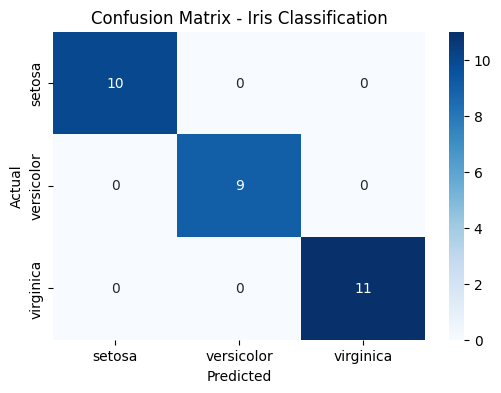

In [11]:
# Step 6: Evaluation
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='weighted')
cm = confusion_matrix(y_test, predictions)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"F1 Score: {f1:.2f}")
print("\n--- Confusion Matrix ---")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Iris Classification')
plt.show()

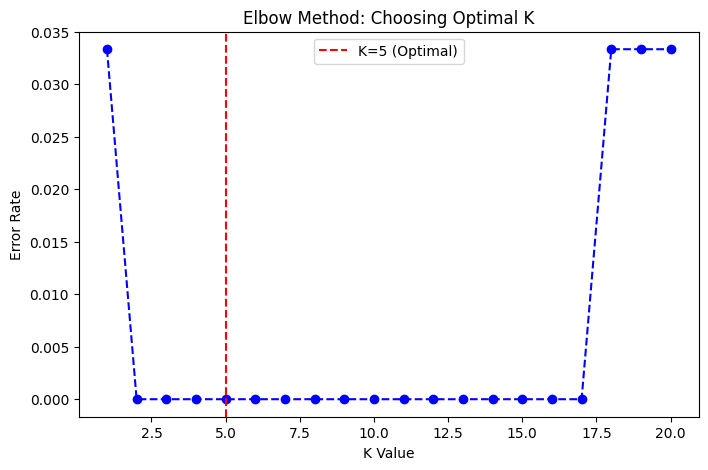

Elbow Method plotted!


In [12]:
# Step 7 (Bonus): Finding Optimal K
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    pred_temp = knn_temp.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, pred_temp))

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, error_rates, marker='o', linestyle='dashed', color='blue')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Elbow Method: Choosing Optimal K')
plt.axvline(x=5, color='red', linestyle='--', label='K=5 (Optimal)')
plt.legend()
plt.show()

print("Elbow Method plotted!")

In [13]:
# Step 8: Predict on New Data
new_flower = [[5.1, 3.5, 1.4, 0.2]]  # Measurements

# Scale the new data (important!)
new_flower_scaled = scaler.transform(new_flower)

prediction = knn.predict(new_flower_scaled)
species = iris.target_names[prediction][0]

print(f"New flower measurements: {new_flower[0]}")
print(f"Predicted species: {species}")

New flower measurements: [5.1, 3.5, 1.4, 0.2]
Predicted species: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
